# Модель для определения примерного возраста по данным о поведении в цифровой среде

#### **Автор:** Пандей В.К.
#### **Дата:** 23.01.26

## Описание проекта
Проект посвящен созданию модели для определения возрастной категории пользователей на основе их цифрового следа. Это поможет показывать рекламу целевой аудитории.

## Задачи
- Провести исследовательский анализ данных.
- Создать и объединить признаки из таблиц.
- Подготовить данные для обучения модели.
- Ошибка f1 должна быть не менее 0.75
- Проанализировать ошибки модели, особенно для несовершеннолетних.
## Описание данных
### users (ds_s13_users.csv)
- `user_id` — уникальный id пользователя
- `age_category` — возрастная категория:
  - 0: младше 18
  - 1: 18-25 лет
  - 2: 26-40 лет
  - 3: 41-55 лет
  - 4: 56+ лет

### visits (ds_s13_visits.csv)
- `date` — дата посещения
- `daytime` — время суток (утро, день, вечер, ночь)
- `session_id` — уникальный id сессии
- `user_id` — id пользователя
- `website_category` — анонимизированная категория сайта

### ads_activity (ads_activity.csv)
- `user_id` — id пользователя
- `ads_activity` — активность с рекламой:
  - очень редко
  - редко
  - умеренно
  - часто
  - очень часто

### surf_depth (surf_depth.csv)
- `user_id` — id пользователя
- `surf_depth` — глубина перехода:
  - поверхностно
  - средне
  - глубоко

### primary_device (primary_device.csv)
- `user_id` — id пользователя
- `primary_device` — тип основного устройства

### cloud_usage (cloud_usage.csv)
- `user_id` — уникальный id пользователя
- `cloud_usage` — использование облачных технологий (True/False):
  - True: пользователь обращается к облачным ресурсам (Яндекс 360 и др.)
  - False: не использует

## Подготовка среды и библиотек

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate, cross_val_predict, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score 
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from utils import aggregate_visits, edit_visits_cats, merge_dfs


RANDOM_STATE = 42

In [4]:
user_df = pd.read_csv('/datasets/ds_s13_users.csv')
print(f'Строк в датасете: {user_df.shape[0]}, столбцов: {user_df.shape[1]}')
print(f'Пропусков:\n{user_df.isnull().sum()}')
user_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/datasets/ds_s13_users.csv'

In [4]:
visits_df = pd.read_csv('/datasets/ds_s13_visits.csv')
print(f'Строк в датасете: {visits_df.shape[0]}, столбцов: {visits_df.shape[1]}')
print(f'Пропусков:\n{visits_df.isnull().sum()}')
print(visits_df['user_id'].nunique())
visits_df.head()

Строк в датасете: 1065745, столбцов: 5
Пропусков:
date                0
daytime             0
session_id          0
user_id             0
website_category    0
dtype: int64
5826


,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


In [5]:
activity_df = pd.read_csv('/datasets/ads_activity.csv')
print(f'Строк в датасете: {activity_df.shape[0]}, столбцов: {activity_df.shape[1]}')
print(f'Пропусков:\n{activity_df.isnull().sum()}')
activity_df.head()

Строк в датасете: 5826, столбцов: 2
Пропусков:
user_id         0
ads_activity    0
dtype: int64


,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно


In [6]:
surf_df = pd.read_csv('/datasets/surf_depth.csv')
print(f'Строк в датасете: {surf_df.shape[0]}, столбцов: {surf_df.shape[1]}')
print(f'Пропусков:\n{surf_df.isnull().sum()}')
surf_df.head()

Строк в датасете: 5715, столбцов: 2
Пропусков:
user_id       0
surf_depth    0
dtype: int64


,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко


In [7]:
device_df = pd.read_csv('/datasets/primary_device.csv')
print(f'Строк в датасете: {device_df.shape[0]}, столбцов: {device_df.shape[1]}')
print(f'Пропусков:\n{device_df.isnull().sum()}')
device_df.head()

Строк в датасете: 5669, столбцов: 2
Пропусков:
user_id           0
primary_device    0
dtype: int64


,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК


In [8]:
cloud_df = pd.read_csv('/datasets/cloud_usage.csv')
print(f'Строк в датасете: {cloud_df.shape[0]}, столбцов: {cloud_df.shape[1]}')
print(f'Пропусков:\n{cloud_df.isnull().sum()}')
cloud_df.head()

Строк в датасете: 5680, столбцов: 2
Пропусков:
user_id        0
cloud_usage    0
dtype: int64


,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


## Исследовательский анализ данных
судя по первичному знакомству с данными, в каждой таблице пользователей разное количество, больше всего уникальных пользователей в `user_df` - 5913, как раз с целевой переменной поэтому будем таблицы все присоединять к ней. Также во всех таблицах нет явных пропусков. Таблицу visits_df перед присоединением надо агрегировать

### user_df

In [9]:
len(user_df[user_df.duplicated()])

87

- 87 явных дубликатов

In [10]:
user_df= user_df.drop_duplicates()

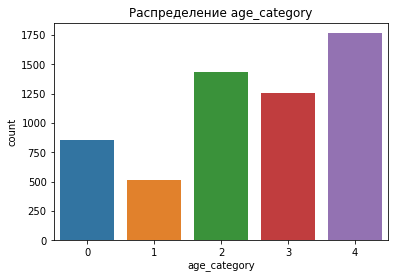

4    30.312393
2    24.699622
3    21.524202
0    14.641263
1     8.822520
Name: age_category, dtype: float64


In [11]:
def bar_category(df, col):
    age_bar = sns.countplot(data=df, x=col)
    plt.title(f'Распределение {col}')
    plt.show()
    print(df[col].value_counts() /df.shape[0] * 100)
bar_category(user_df, 'age_category')

распределение по возрастной категории:
1. 56+ лет          - 30.3%
2. 26-40 лет        - 24.7%
3. 41-55 лет        - 21.5%
4. младше 18        - 14.6%
5. 18-25 лет        -  8.8%
- наблюдается дисбаланс целевой переменной

### visits_df

In [12]:
visits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   daytime           1065745 non-null  object
 2   session_id        1065745 non-null  object
 3   user_id           1065745 non-null  object
 4   website_category  1065745 non-null  object
dtypes: object(5)
memory usage: 40.7+ MB


In [13]:
for i in ['date', 'daytime', 'website_category']:
    print(i)
    print(visits_df[i].nunique()) 
    print(visits_df[i].unique())

date
14
['2025-11-01' '2025-11-02' '2025-11-03' '2025-11-04' '2025-11-05'
 '2025-11-06' '2025-11-07' '2025-11-08' '2025-11-09' '2025-11-10'
 '2025-11-11' '2025-11-12' '2025-11-13' '2025-11-14']
daytime
4
['вечер' 'день' 'ночь' 'утро']
website_category
20
['Category 17' 'Category 19' 'Category 18' 'Category 20' 'Category 05'
 'Category 12' 'Category 03' 'Category 15' 'Category 10' 'Category 06'
 'Category 04' 'Category 09' 'Category 01' 'Category 11' 'Category 07'
 'Category 14' 'Category 08' 'Category 13' 'Category 02' 'Category 16']


- период наблюдений: 01.11.2025 - 14.11.2025. Категорий вебсайтов всего 20. Неявных дубликатов не обнаружено

In [14]:
len(visits_df[visits_df.duplicated()])

15750

- 15750 явных дубликатов

In [15]:
visits_df= visits_df.drop_duplicates()

In [16]:
visits_df['website_category'].value_counts()

Category 03    69129
Category 13    67647
Category 05    59720
Category 06    56243
Category 08    55195
Category 19    54568
Category 07    53906
Category 09    53089
Category 01    52401
Category 10    52043
Category 15    51462
Category 04    51072
Category 20    50419
Category 18    50336
Category 12    49940
Category 17    49130
Category 16    45685
Category 14    45525
Category 02    43822
Category 11    38663
Name: website_category, dtype: int64

- с помощью агрегации сделаем такие столбцы:
  - кол-во посещений
  - любимое время суток
  - любимая категория
  - кол-во уникальных категорий
  - кол-во уникальных дат посещений
  - активность по времени суток
  - кол-во посещений каждой категории

In [17]:
visits_agg = agregate_visits(visits_df)
visits_agg.head()

,total_visits,favorite_daytime,favorite_category,category_count,date_count,cat_Category_01,cat_Category_02,cat_Category_03,cat_Category_04,cat_Category_05,...,cat_Category_15,cat_Category_16,cat_Category_17,cat_Category_18,cat_Category_19,cat_Category_20,pct_вечер,pct_день,pct_ночь,pct_утро
user_id,,,,,,,,,,,,,,,,,,,,,
0010-5cf8f6b38a7b6c70a021-009dbcda,546,вечер,Category 19,19,14,16,0,34,23,18,...,15,33,28,43,50,50,0.413919,0.326007,0.095238,0.164835
0013-4ae5f7d127b91a3fb0f8-ba59f141,185,день,Category 08,19,14,15,11,5,7,15,...,3,8,12,16,1,4,0.275676,0.372973,0.086486,0.264865
0014-d3032d60979a8d2b3077-f09bdce8,117,день,Category 13,19,14,1,2,4,7,8,...,7,2,9,3,12,4,0.307692,0.384615,0.094017,0.213675
001a-eee53e44f848608779b0-78704a67,287,вечер,Category 14,19,14,19,13,10,22,10,...,12,9,13,21,21,17,0.414634,0.334495,0.108014,0.142857
002c-40a064b12e1217e12207-a56eaf3b,490,день,Category 13,18,14,0,26,35,30,20,...,22,20,17,6,25,27,0.295918,0.383673,0.069388,0.251020


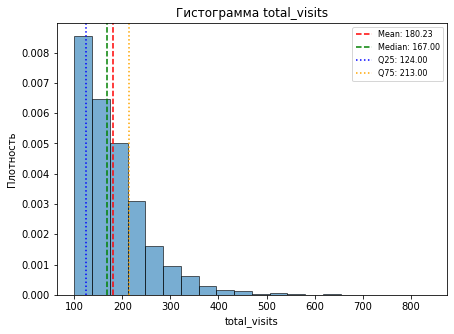

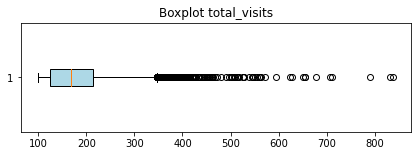

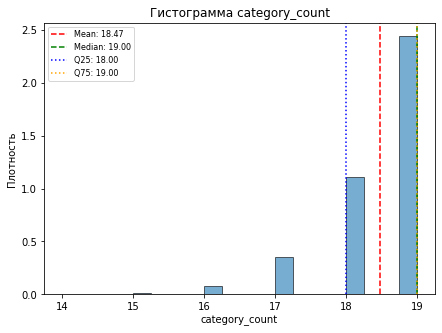

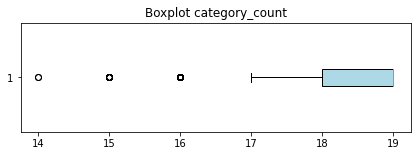

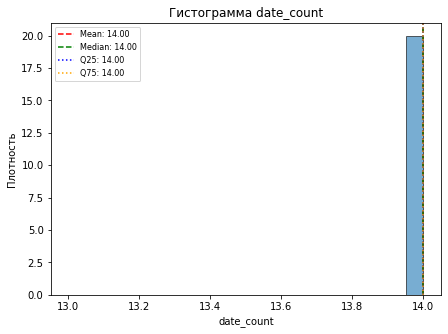

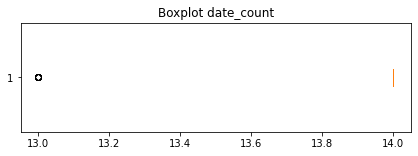

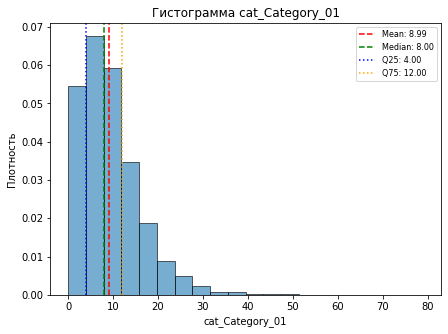

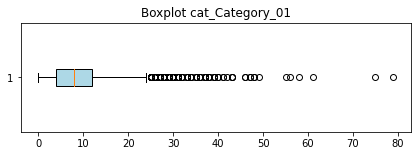

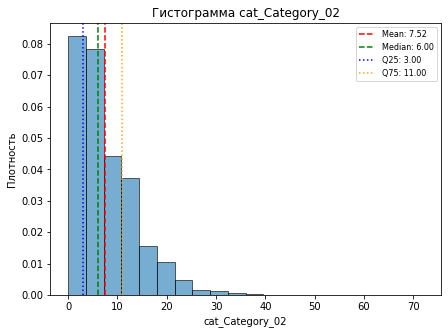

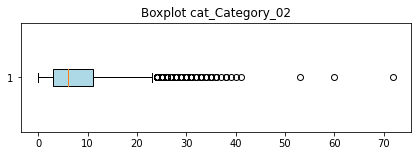

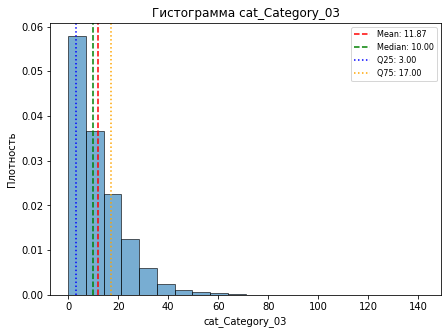

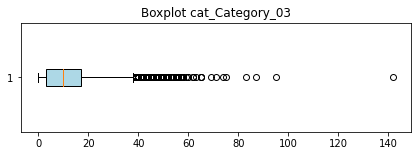

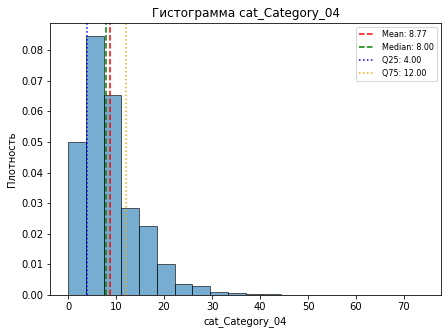

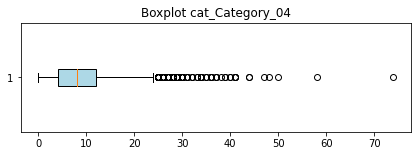

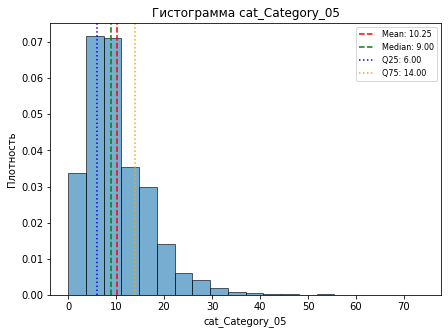

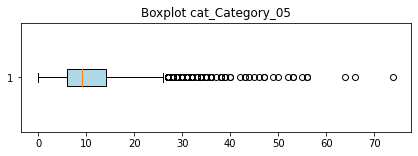

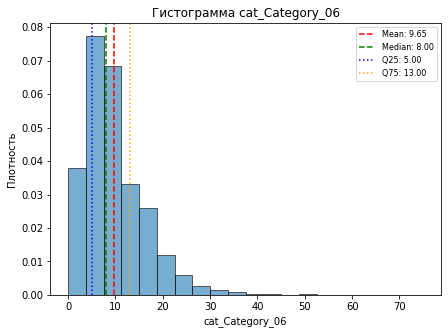

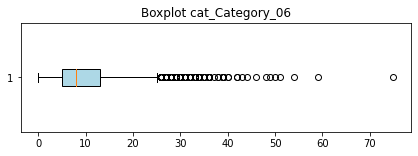

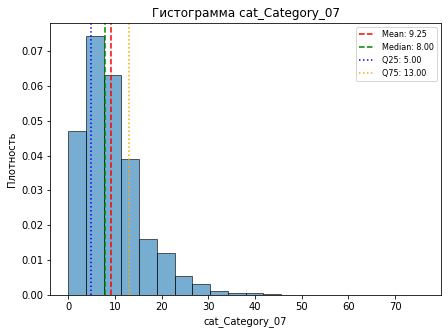

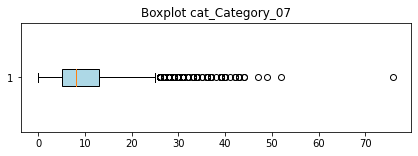

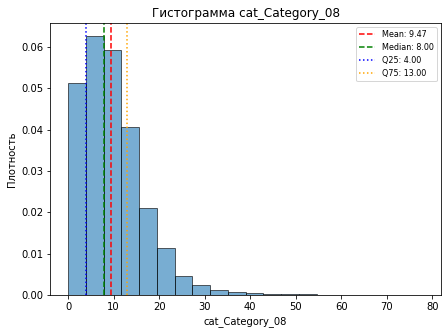

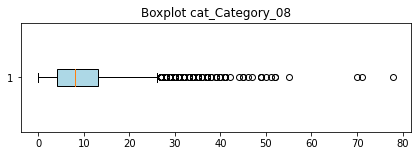

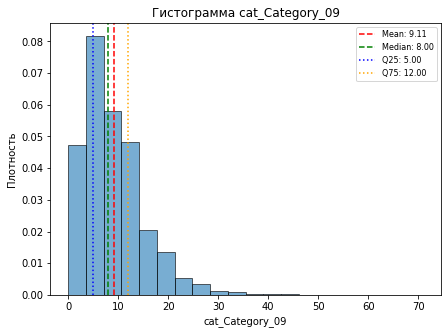

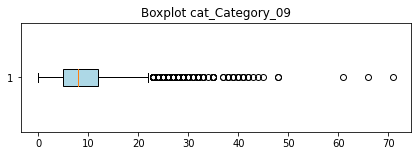

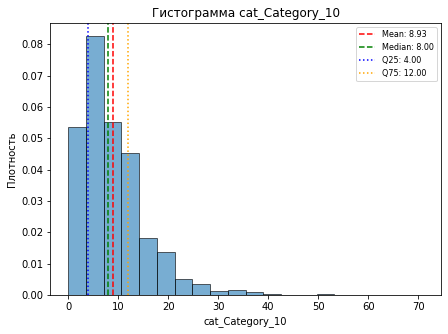

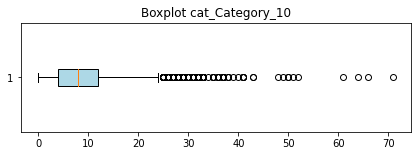

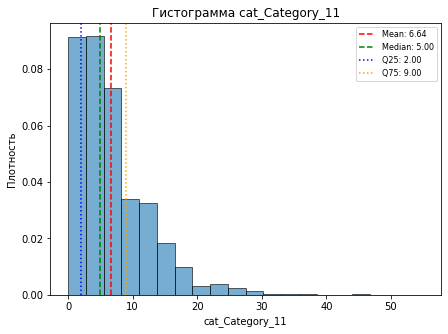

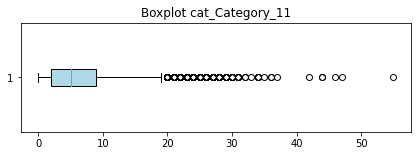

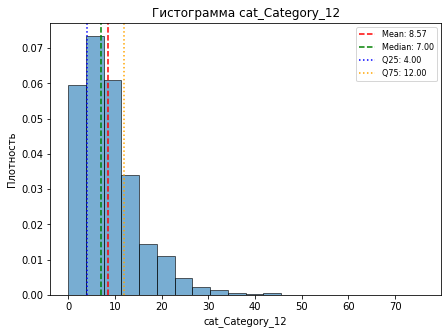

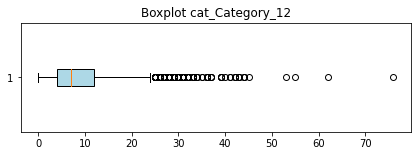

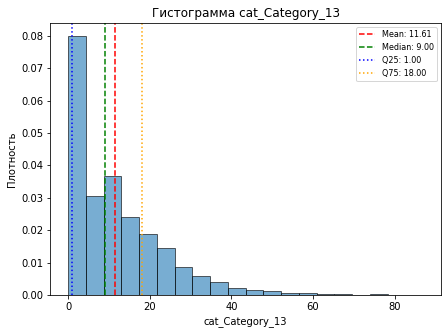

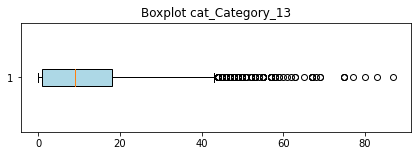

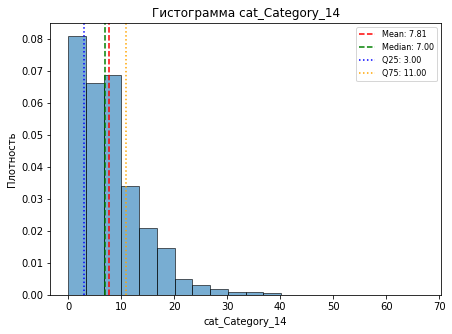

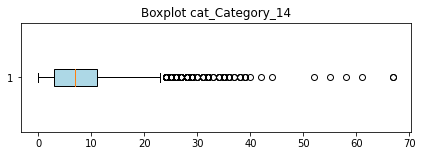

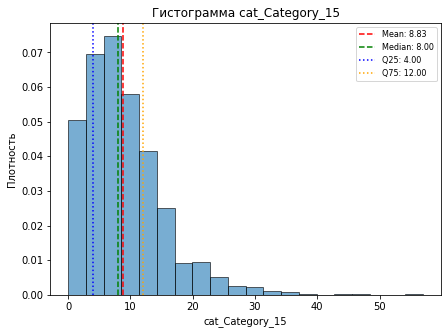

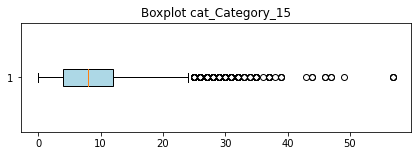

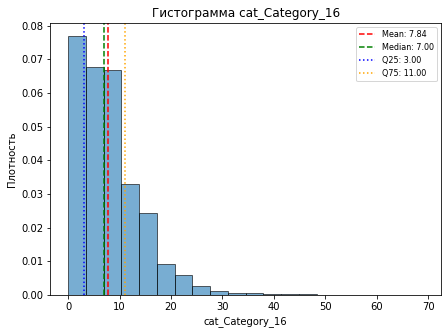

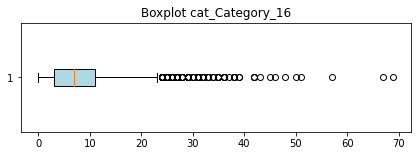

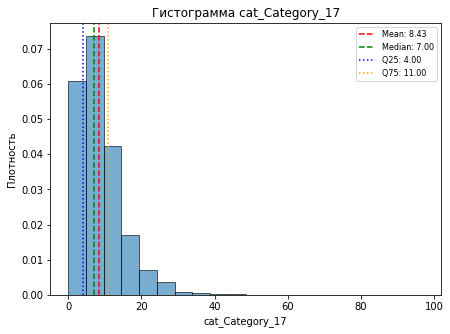

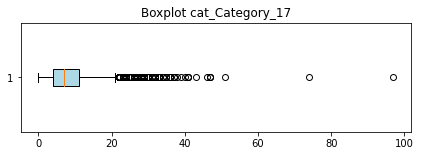

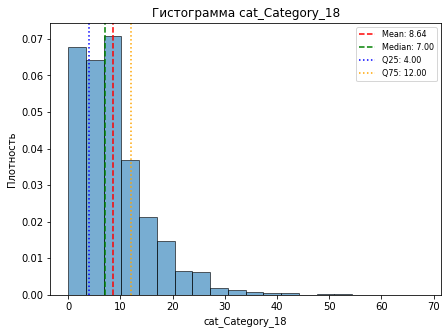

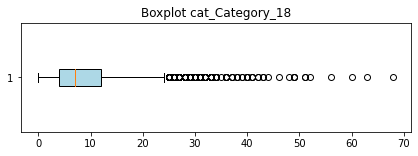

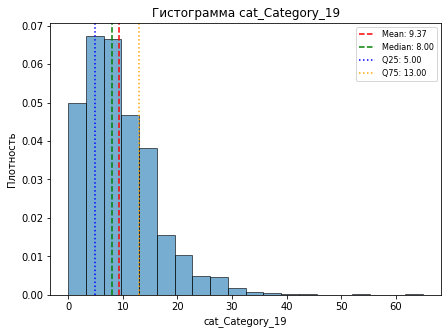

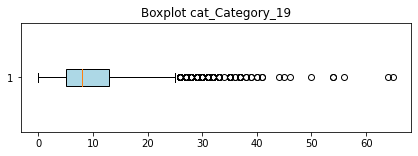

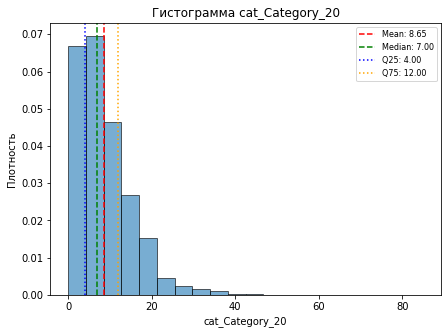

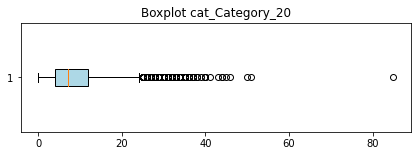

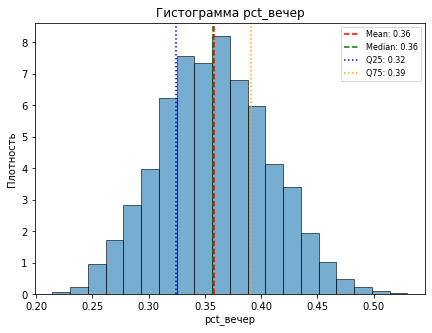

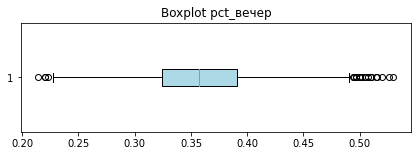

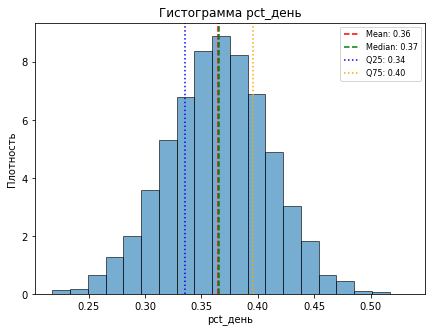

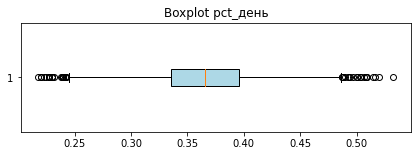

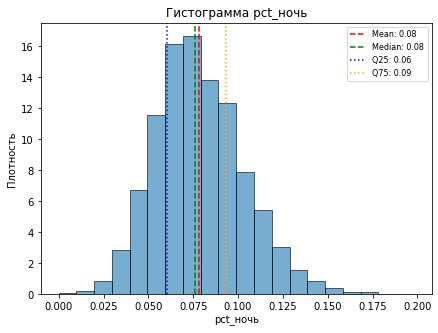

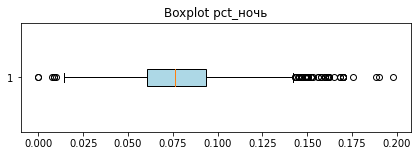

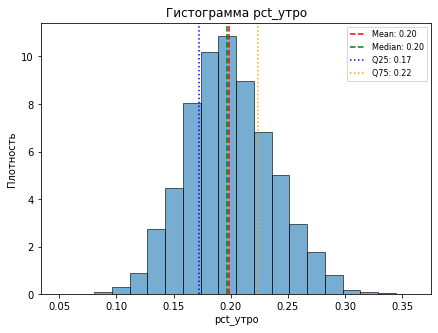

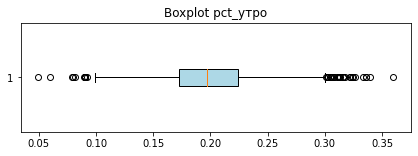

In [18]:
def eda_numeric_data(df):
    numeric_features = df.select_dtypes(include=['float','int']).columns
    
    for col in numeric_features:
        data = df[col]
        
        plt.figure(figsize=(7,5))
        hist = plt.hist(data, bins=20, density=True, alpha=0.6, edgecolor='black')
        mean_val = data.mean()
        median_val = data.median()
        q25 = data.quantile(0.25)
        q75 = data.quantile(0.75)
        
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
        plt.axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
        plt.axvline(q25, color='blue', linestyle=':', linewidth=1.5, label=f'Q25: {q25:.2f}')
        plt.axvline(q75, color='orange', linestyle=':', linewidth=1.5, label=f'Q75: {q75:.2f}')
        plt.title(f'Гистограмма {col}')
        plt.xlabel(col)
        plt.ylabel('Плотность')
        plt.legend(fontsize=8)
        plt.show()  

        plt.figure(figsize=(7, 2))
        box = plt.boxplot(data, vert=0, patch_artist=True)
        box['boxes'][0].set_facecolor('lightblue')  
        plt.title(f'Boxplot {col}')
        plt.show()

eda_numeric_data(visits_agg)

- распределение столбцов `total_visits` и `cat_Category` 1-20 сильно скошено и много выбросов на больших значениях, применим логарифмирование, чтобы избавиться от выбросов

In [19]:
visits_agg = edit_visits_cats(visits_agg)

### activity_df

In [20]:
activity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5826 non-null   object
 1   ads_activity  5826 non-null   object
dtypes: object(2)
memory usage: 91.2+ KB


In [21]:
len(activity_df[activity_df.duplicated()])

233

- 233 явных дубликатов

In [22]:
activity_df = activity_df.drop_duplicates()
print(activity_df['ads_activity'].unique())

['очень часто' 'редко' 'очень редко' 'умеренно' 'часто']


- неявных дубликатов в категориях не обнаружено

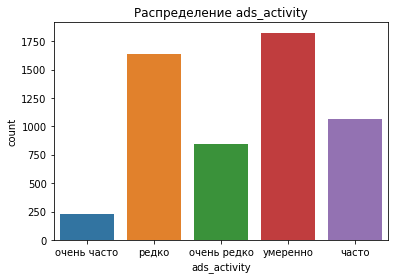

умеренно       32.612194
редко          29.215090
часто          19.113177
очень редко    15.036653
очень часто     4.022886
Name: ads_activity, dtype: float64


In [23]:
bar_category(activity_df, 'ads_activity')

- больше всего пользователей умеренно взаимодействуют с рекламой
- меньше всего пользователей взаимодействуют с рекламой очень часто

### surf_df

In [24]:
surf_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB


In [25]:
len(surf_df[surf_df.duplicated()])

0

- нет явных дубликатов

In [26]:
print(surf_df['surf_depth'].unique())

['поверхностно' 'глубоко' 'средне']


- нет неявных дубликатов

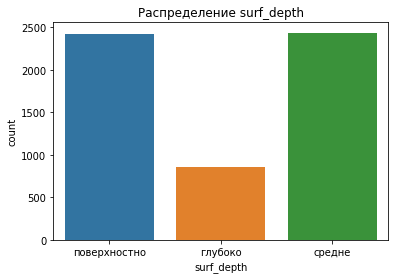

средне          42.607174
поверхностно    42.414698
глубоко         14.978128
Name: surf_depth, dtype: float64


In [27]:
bar_category(surf_df, 'surf_depth')

- одинаково часто пользователи серфят по интернету поверхтносто и средне
- меньше всего пользователей глубоко переходят в интернете

### device_df

In [28]:
device_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB


In [29]:
len(device_df[device_df.duplicated()])

0

- нет явных дубликатов

In [30]:
print(device_df['primary_device'].unique())

['смартфон' 'ПК' 'ноутбук' 'планшет']


- нет неявных дубликатов

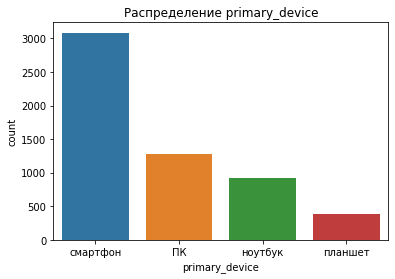

смартфон    54.383489
ПК          22.490739
ноутбук     16.281531
планшет      6.844241
Name: primary_device, dtype: float64


In [31]:
bar_category(device_df, 'primary_device')

- половина пользователей посещают сайт с телефона, меньше всего - с планшета

### cloud_df

In [32]:
cloud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.0+ KB


In [33]:
len(cloud_df[cloud_df.duplicated()])

0

- нет явных дубликатов

In [34]:
print(cloud_df['cloud_usage'].value_counts())

True     2951
False    2729
Name: cloud_usage, dtype: int64


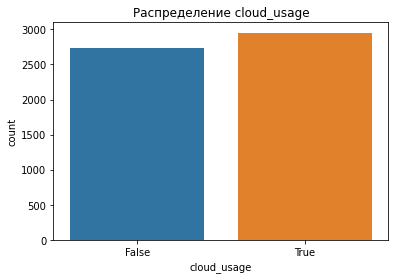

True     51.954225
False    48.045775
Name: cloud_usage, dtype: float64


In [35]:
bar_category(cloud_df, 'cloud_usage')

- половина пользователей пользуется облаком, половина - не пользуется

### Подготовка датасета

In [36]:
dfs_to_merge = [user_df, visits_agg, activity_df, surf_df, device_df, cloud_df]
df = merge_dfs(dfs_to_merge, on='user_id', how='left')
df.head()

,user_id,age_category,favorite_daytime,favorite_category,category_count,date_count,pct_вечер,pct_день,pct_ночь,pct_утро,...,log_cat_Category_15,log_cat_Category_16,log_cat_Category_17,log_cat_Category_18,log_cat_Category_19,log_cat_Category_20,ads_activity,surf_depth,primary_device,cloud_usage
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,день,Category 05,19,14,0.336898,0.358289,0.074866,0.229947,...,2.397895,2.197225,2.484907,2.639057,2.708050,2.197225,NaN,глубоко,смартфон,False
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,вечер,Category 07,19,14,0.390071,0.340426,0.092199,0.177305,...,2.302585,1.791759,1.791759,1.609438,1.791759,1.791759,умеренно,средне,смартфон,False
2,678b-614cd47d854b9d591db2-000b2e50,0,вечер,Category 12,17,14,0.380000,0.290000,0.130000,0.200000,...,1.098612,1.386294,1.098612,0.693147,2.484907,1.945910,умеренно,средне,смартфон,False
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,день,Category 18,19,14,0.258065,0.439516,0.072581,0.229839,...,1.945910,2.079442,2.833213,3.526361,2.302585,1.386294,редко,поверхностно,смартфон,True
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,вечер,Category 12,19,14,0.420168,0.344538,0.075630,0.159664,...,1.386294,1.386294,1.945910,1.609438,1.386294,2.079442,очень редко,поверхностно,смартфон,True


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5826 entries, 0 to 5825
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              5826 non-null   object 
 1   age_category         5826 non-null   int64  
 2   favorite_daytime     5826 non-null   object 
 3   favorite_category    5826 non-null   object 
 4   category_count       5826 non-null   int64  
 5   date_count           5826 non-null   int64  
 6   pct_вечер            5826 non-null   float64
 7   pct_день             5826 non-null   float64
 8   pct_ночь             5826 non-null   float64
 9   pct_утро             5826 non-null   float64
 10  log_total_visits     5826 non-null   float64
 11  log_cat_Category_01  5826 non-null   float64
 12  log_cat_Category_02  5826 non-null   float64
 13  log_cat_Category_03  5826 non-null   float64
 14  log_cat_Category_04  5826 non-null   float64
 15  log_cat_Category_05  5826 non-null   f

- в итоговом датасете получилось 5826 пользователей, пропуски обнаружены только в столбцах `ads_activity`, `surf_depth`, `primary_device`, `cloud_usage`
- посмотрим распределение целевой переменной

### Матрица корелляций

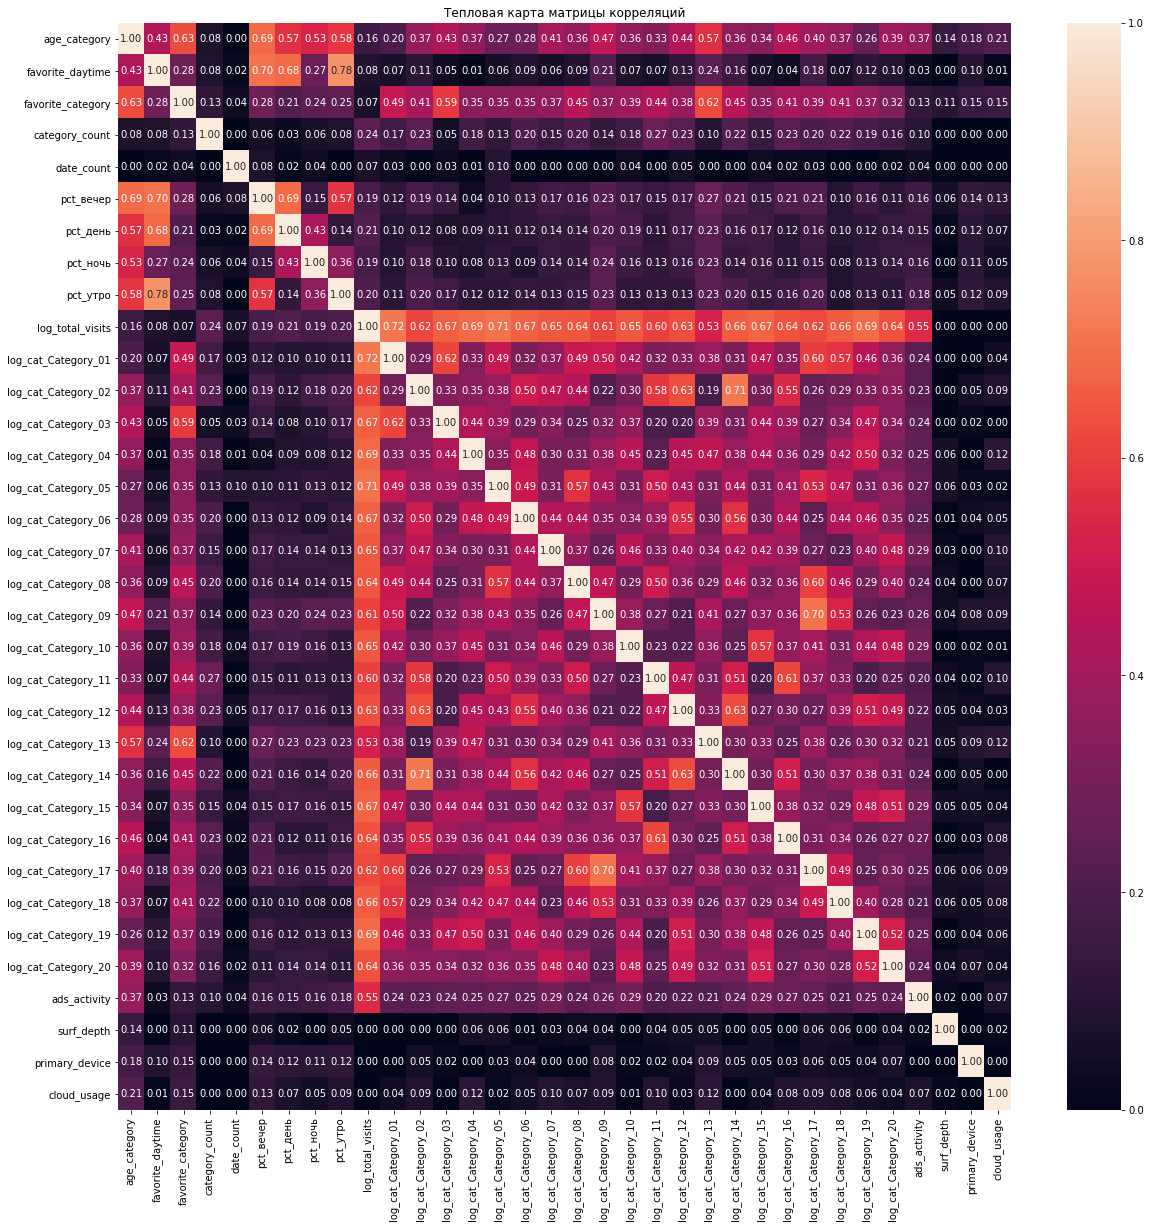

In [38]:
X = df.drop(columns=(['user_id']))
y = df['age_category'] 
matrix = X.phik_matrix(interval_cols=X.select_dtypes(include=['float','int']).columns)
plt.figure(figsize=(20,20))
sns.heatmap(data=matrix, fmt='.2f',annot=True)
plt.title('Тепловая карта матрицы корреляций')
plt.show()

- удалим столбцы `category_count`, `date_count`, `cat_Category_01`, `cat_Category_03` в связи с очень маленькой корелляцией с целевой переменной
- мультикорелляции между признаками не наблюдается

### Выводы по EDA

Данные в целом качественные: 6146 пользователей, минимальные пропуски в 4 столбцах. Основные проблемы: дисбаланс целевой переменной и скошенное распределение total_visits.
1) Удалили слабые признаки (category_count, date_count, cat_Category_01, cat_Category_03)
2) Применили логарифмирование total_visits для нормализации
3) Выявили демографический перекос (30.6% пользователей 56+ лет, всего 8.7% молодежи 18-25)
4) Мультиколлинеарность между ключевыми признаками не обнаружена.
Датасет подготовлен для построения классификационных моделей с учетом дисбаланса ( class_weight='balanced' и F1-score как метрику).

## Разделение данных на выборки


In [39]:
features_to_drop = ['category_count', 'date_count', 'age_category', 'log_cat_Category_01', 'log_cat_Category_03']
X = X.drop(columns=features_to_drop)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
print('размеры выборок')
print(f'X_train: {X_train.shape[0]}, y_train: {y_train.shape[0]}')
print(f'X_test: {X_test.shape[0]}, y_test: {y_test.shape[0]}')

размеры выборок
X_train: 4078, y_train: 4078
X_test: 1748, y_test: 1748


## Предобработка данных


In [40]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include=['float','int']).columns
column_prep = ColumnTransformer(transformers=[
    ('cat',
     Pipeline(steps=[
              ('imputer', SimpleImputer(strategy='most_frequent')),
              ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
              ]),
     cat_cols),
    ('num', 
         Pipeline(steps=[
             ('imputer', SimpleImputer(strategy='mean')),
             ('scaler', StandardScaler())
         ]),
         num_cols)
    ])
preprocessor = Pipeline(steps=[
    ('columns', column_prep),
    ('feature_selection', RFE(
        estimator=LogisticRegression(
            random_state=RANDOM_STATE,
            class_weight='balanced',
            solver='lbfgs',
            max_iter=1000
        ),
        n_features_to_select=30,  
        step=1  
        )
    )
])

## Обучение базовой модели


In [41]:
base_model = DummyClassifier()
scoring = ['f1_macro', 'precision_macro', 'recall_macro']
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_base = cross_validate(base_model, X_train, y_train, scoring=scoring, cv=kfold)
    
def print_cv_results(cv_results):
    print("Результаты модели:")
    print(f"F1 Score: {cv_results['test_f1_macro'].mean():.3f}")
    print(f"Precision: {cv_results['test_precision_macro'].mean():.3f}")
    print(f"Recall: {cv_results['test_recall_macro'].mean():.3f}")

print_cv_results(cv_base)

Результаты модели:
F1 Score: 0.093
Precision: 0.061
Recall: 0.200


/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metri

- базовая модель работает и задает начальный уровень качества, теперь можно строить обучать и сравнивать реальные модели


## Подбор гиперпараметров моделей


In [42]:
X_train_processed = preprocessor.fit_transform(X_train, y_train)

results = []

ovr = OneVsRestClassifier(
        estimator=LogisticRegression(random_state=RANDOM_STATE,
                                     class_weight='balanced'))

param_grid_ovr = {'estimator__max_iter': [1000, 2000],
                  'estimator__C': [0.01, 0.1, 1, 10],
                  'estimator__solver': ['lbfgs', 'liblinear']}

ovr_grid = GridSearchCV(
    ovr,
    param_grid_ovr,
    cv=3,
    scoring='f1_macro',
    n_jobs=1,  
    verbose=1
)

ovr_grid.fit(X_train_processed, y_train)

ovo = OneVsOneClassifier(
        estimator=LogisticRegression(random_state=RANDOM_STATE,
                                     class_weight='balanced'))

param_grid_ovo = {'estimator__max_iter': [1000, 2000],
                  'estimator__C': [0.01, 0.1, 1, 10],
                  'estimator__solver': ['lbfgs', 'liblinear']}

ovo_grid = GridSearchCV(
    ovo,
    param_grid_ovo,
    cv=3,
    scoring='f1_macro',
    n_jobs=1,  
    verbose=1
)

ovo_grid.fit(X_train_processed, y_train)

logreg = LogisticRegression(random_state=RANDOM_STATE,
                               class_weight='balanced',
                               solver='lbfgs')

param_grid_logreg = {'max_iter': [1000, 2000, 5000],
                  'C': [0.01, 0.1, 1, 10]}

logreg_grid = GridSearchCV(
    logreg,
    param_grid_logreg,
    cv=3,
    scoring='f1_macro',
    n_jobs=1,  
    verbose=1
)

logreg_grid.fit(X_train_processed, y_train)

for i, params in enumerate(ovr_grid.cv_results_['params']):
    results.append({
        'model': ' OneVsRest',
        'params': str(params),
        'f1_macro': ovr_grid.cv_results_['mean_test_score'][i],
        'std': ovr_grid.cv_results_['std_test_score'][i]
    })
    
for i, params in enumerate(ovo_grid.cv_results_['params']):
    results.append({
        'model': ' OneVsOne',
        'params': str(params),
        'f1_macro': ovo_grid.cv_results_['mean_test_score'][i],
        'std': ovo_grid.cv_results_['std_test_score'][i]
    })

for i, params in enumerate(logreg_grid.cv_results_['params']):
    results.append({
        'model': 'LogisticRegression',
        'params': str(params),
        'f1_macro': logreg_grid.cv_results_['mean_test_score'][i],
        'std': logreg_grid.cv_results_['std_test_score'][i]
    })

results_df = pd.DataFrame(results)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits


## Топ-10 конфигураций модели


In [43]:
pd.set_option('display.max_colwidth', None)
results_df.sort_values('f1_macro', ascending=False).head(10)

,model,params,f1_macro,std
40,LogisticRegression,"{'C': 1, 'max_iter': 5000}",0.813928,0.000163
39,LogisticRegression,"{'C': 1, 'max_iter': 2000}",0.813928,0.000163
38,LogisticRegression,"{'C': 1, 'max_iter': 1000}",0.813928,0.000163
37,LogisticRegression,"{'C': 0.1, 'max_iter': 5000}",0.812863,0.008443
36,LogisticRegression,"{'C': 0.1, 'max_iter': 2000}",0.812863,0.008443
35,LogisticRegression,"{'C': 0.1, 'max_iter': 1000}",0.812863,0.008443
27,OneVsOne,"{'estimator__C': 1, 'estimator__max_iter': 2000, 'estimator__solver': 'liblinear'}",0.812393,0.002885
25,OneVsOne,"{'estimator__C': 1, 'estimator__max_iter': 1000, 'estimator__solver': 'liblinear'}",0.812393,0.002885
43,LogisticRegression,"{'C': 10, 'max_iter': 5000}",0.811471,0.001743
42,LogisticRegression,"{'C': 10, 'max_iter': 2000}",0.811471,0.001743


Лучшей моделью с наибольшим показателем метрики f1_macro является LogisticRegression с параметрами:
- {'C': 1, 'max_iter': 5000}	
- у этой модели значение f1_macro = 0.81

## Лучшая модель

In [44]:
best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE,
                               class_weight='balanced',
                               solver='lbfgs',
                                max_iter=5000,
                                C=1))
])
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("classification report:")
print(classification_report(y_test, y_pred))
print("\nConfusion matrix:")
print(pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted']))

classification report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       256
           1       0.56      0.74      0.64       154
           2       0.84      0.79      0.81       432
           3       0.82      0.83      0.83       376
           4       0.90      0.86      0.88       530

    accuracy                           0.82      1748
   macro avg       0.79      0.81      0.80      1748
weighted avg       0.83      0.82      0.82      1748


Confusion matrix:
Predicted    0    1    2    3    4
True                              
0          208   26   18    2    2
1           17  114   13    7    3
2           13   45  340   14   20
3           11   10   17  313   25
4            2   10   16   46  456


модель показывает очень хорошие стабильные результаты на предсказании всех классов тестовой выборки. Метрика f1_macro = 0.80 - модель можно выпускать в продакшн

## Подготовка артефактов модели для внедрения

In [46]:
joblib.dump(best_model, 'final_model.joblib')
joblib.dump(preprocessor, 'preprocessor.joblib')
feature_info = {
    'num_cols': num_cols,
    'cat_cols': cat_cols
}
joblib.dump(feature_info, 'feature_info.joblib')

print("Загрузка и проверка")

loaded_pipeline = joblib.load('final_model.joblib')
loaded_preprocessor = joblib.load('preprocessor.joblib')
loaded_feature_info = joblib.load('feature_info.joblib')

print(f"Пайплайн: {type(loaded_pipeline)}")
print(f"Препроцессор: {type(loaded_preprocessor)}")
print(f"Признаки: {loaded_feature_info}")
visits_df_l = agregate_visits(visits_df)
visits_df_l = edit_visits_cats(visits_df_l)
dfs_to_merge_l = [user_df, visits_df_l, activity_df, surf_df, device_df, cloud_df]
df1 = merge_dfs(dfs_to_merge_l, on='user_id', how='left')
X1 = df1.drop(columns='age_category')
y1 = df1['age_category']
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X1, y1, test_size=0.3, random_state=RANDOM_STATE, stratify=y1)

print('\nПроверка на тестовых данных:')
y_pred_test_loaded = loaded_pipeline.predict(X_test_1)
print("classification report:")
print(classification_report(y_test_1, y_pred_test_loaded))
print("\nConfusion matrix:")
print(pd.crosstab(y_test_1, y_pred_test_loaded, rownames=['True'], colnames=['Predicted']))

Загрузка и проверка
Пайплайн: <class 'sklearn.pipeline.Pipeline'>
Препроцессор: <class 'sklearn.pipeline.Pipeline'>
Признаки: {'num_cols': Index(['pct_вечер', 'pct_день', 'pct_ночь', 'pct_утро', 'log_total_visits',
       'log_cat_Category_02', 'log_cat_Category_04', 'log_cat_Category_05',
       'log_cat_Category_06', 'log_cat_Category_07', 'log_cat_Category_08',
       'log_cat_Category_09', 'log_cat_Category_10', 'log_cat_Category_11',
       'log_cat_Category_12', 'log_cat_Category_13', 'log_cat_Category_14',
       'log_cat_Category_15', 'log_cat_Category_16', 'log_cat_Category_17',
       'log_cat_Category_18', 'log_cat_Category_19', 'log_cat_Category_20'],
      dtype='object'), 'cat_cols': Index(['favorite_daytime', 'favorite_category', 'ads_activity', 'surf_depth',
       'primary_device', 'cloud_usage'],
      dtype='object')}

Проверка на тестовых данных:
classification report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82

## Финальный отчет

- Метрики `DummyClassifier`:
  - F1 Score macro: 0.094
  - Precision macro: 0.061
  - Recall macro: 0.200
  
- Метрики финальной модели:
  - F1 Score macro: 0.80
  - Precision macro: 0.79
  - Recall macro: 0.81

## Выводы
- По сравнению с базовой моделью финальная модель показывает очень хорошие и стабильные результаты
- `LogisticRegression` c параметрами {'C': 1, 'max_iter': 5000, 'solver': 'lbfgs'} очень точно и полно предсказывает все классы целевой переменной. 
- Модель готова к выпуску в продакшн